# Chess Elo Prediction — Improved Approach

## What changed and why

The original notebook used surface-level game statistics (captures, checks, castling) to predict Elo. These barely correlate with skill — a 1500 and a 2800 player can both castle and make captures.

**The core insight:** The dataset already includes engine evaluations for each move. The single strongest predictor of skill is **centipawn loss per move** — how far a player's actual move deviates from the engine's best move. A 2800 Elo player loses ~20 centipawns/move on average; a 2200 player loses ~60.

This notebook builds on that:
1. **Engine-based features**: average centipawn loss, blunder/mistake/inaccuracy rates, move quality consistency (std dev)
2. **Phase-aware features**: opening/middlegame/endgame centipawn loss separately (skill profiles differ by phase)
3. **Tactical features**: missed tactics rate, best-move agreement rate
4. **One shared model** with a player-color indicator — no need for two separate models
5. **XGBoost** with cross-validated hyperparameters
6. **Proper validation**: 5-fold CV + held-out test set

In [ ]:
%pip install python-chess xgboost lightgbm -q

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import chess.pgn
import chess
import pandas as pd
import numpy as np
from collections import defaultdict
import re
import warnings
warnings.filterwarnings('ignore')

## Feature Extraction

The Kaggle dataset stores engine scores as comments on each move in the PGN, typically in the format `{ [%eval 0.35] }` or as centipawn values. We extract these and compute quality metrics per player.

**Centipawn loss thresholds** (standard in chess analysis tools like Lichess):
- Inaccuracy: 50–100 cp loss
- Mistake: 100–200 cp loss  
- Blunder: 200+ cp loss

In [ ]:
def parse_eval(comment: str):
    """
    Extract centipawn evaluation from a PGN move comment.
    Handles formats: [%eval 0.35], [%eval #5], raw numbers like +35 or -12.
    Returns centipawns as int, or None if not found.
    Caps at ±1000 cp to avoid mate scores skewing stats.
    """
    if not comment:
        return None
    
    # Mate score — treat as large cp value
    mate_match = re.search(r'\[%eval #(-?\d+)\]', comment)
    if mate_match:
        return 1000 if int(mate_match.group(1)) > 0 else -1000
    
    # Numeric eval in pawns (e.g., 0.35 or -1.20)
    eval_match = re.search(r'\[%eval (-?\d+\.?\d*)\]', comment)
    if eval_match:
        cp = int(float(eval_match.group(1)) * 100)
        return max(-1000, min(1000, cp))
    
    # Fallback: raw centipawn integer in comment
    raw_match = re.search(r'([+-]?\d+)', comment)
    if raw_match:
        cp = int(raw_match.group(1))
        return max(-1000, min(1000, cp))
    
    return None


def classify_game_phase(move_number: int, total_moves: int) -> str:
    """
    Rough phase split by move number.
    Opening: first ~15 moves, Endgame: last 20%, Middlegame: everything else.
    """
    if move_number <= 15:
        return 'opening'
    elif move_number >= total_moves * 0.8:
        return 'endgame'
    else:
        return 'middlegame'


def extract_player_stats(cp_losses: list) -> dict:
    """
    Given a list of centipawn losses for one player's moves,
    return a dict of quality metrics.
    """
    if not cp_losses:
        return {k: 0 for k in [
            'avg_cp_loss', 'median_cp_loss', 'std_cp_loss',
            'blunder_rate', 'mistake_rate', 'inaccuracy_rate',
            'good_move_rate', 'worst_move_cp_loss', 'move_count'
        ]}
    
    arr = np.array(cp_losses)
    n = len(arr)
    
    return {
        'avg_cp_loss':      float(np.mean(arr)),
        'median_cp_loss':   float(np.median(arr)),
        'std_cp_loss':      float(np.std(arr)),      # consistency
        'blunder_rate':     float(np.mean(arr >= 200)),
        'mistake_rate':     float(np.mean((arr >= 100) & (arr < 200))),
        'inaccuracy_rate':  float(np.mean((arr >= 50) & (arr < 100))),
        'good_move_rate':   float(np.mean(arr < 20)),   # near-perfect moves
        'worst_move_cp_loss': float(np.max(arr)),
        'move_count':       n,
    }


def extract_features(game) -> list[dict]:
    """
    Extract one row per player (white + black) from a game.
    Returns a list of 2 dicts: [white_row, black_row].
    
    Key design decision: we output one row per player, not one row per game.
    This lets us use a single model and doubles our training data.
    """
    white_elo = int(game.headers.get('WhiteElo', 0))
    black_elo = int(game.headers.get('BlackElo', 0))
    
    if white_elo == 0 or black_elo == 0:
        return []
    
    result_str = game.headers.get('Result', '*')
    result_map = {'1-0': 1.0, '0-1': 0.0, '1/2-1/2': 0.5}
    result = result_map.get(result_str, 0.5)
    
    board = game.board()
    node = game
    
    # Collect cp losses per player, overall and by phase
    w_losses = defaultdict(list)  # phase -> [cp_loss]
    b_losses = defaultdict(list)
    
    move_number = 0
    prev_eval = None  # engine eval BEFORE this move
    all_moves = list(game.mainline_moves())
    total_moves = len(all_moves)
    
    for move in all_moves:
        move_number += 1
        is_white = board.turn  # True = white to move
        node = node.next()
        comment = node.comment if node else ''
        
        current_eval = parse_eval(comment)
        
        if prev_eval is not None and current_eval is not None:
            # cp loss = how much the position got worse for the side that just moved
            if is_white:
                # White just moved. Eval is from white's perspective.
                # Before move: prev_eval (white's perspective). After: current_eval.
                # If eval drops, white played badly.
                cp_loss = max(0, prev_eval - current_eval)
            else:
                # Black just moved. Eval flips sign convention.
                cp_loss = max(0, current_eval - prev_eval)  # higher eval after = black lost material
                # Actually: from black's perspective, prev position had eval = -prev_eval,
                # after move = -current_eval. Loss = max(0, -prev_eval - (-current_eval)) = max(0, current_eval - prev_eval)
            
            phase = classify_game_phase(move_number, total_moves)
            
            if is_white:
                w_losses['all'].append(cp_loss)
                w_losses[phase].append(cp_loss)
            else:
                b_losses['all'].append(cp_loss)
                b_losses[phase].append(cp_loss)
        
        prev_eval = current_eval
        board.push(move)
    
    # Also collect structural features (opponent Elo context, game length)
    def build_row(color: str, own_losses, opp_elo, own_elo, won_result):
        stats = extract_player_stats(own_losses['all'])
        opening_stats = extract_player_stats(own_losses.get('opening', []))
        mid_stats     = extract_player_stats(own_losses.get('middlegame', []))
        end_stats     = extract_player_stats(own_losses.get('endgame', []))
        
        row = {
            'color':         1 if color == 'white' else 0,
            'result':        won_result,   # 1=won, 0.5=draw, 0=lost (from this player's view)
            'opp_elo':       opp_elo,
            'total_game_moves': total_moves,
            'target_elo':    own_elo,
        }
        
        # Overall stats
        for k, v in stats.items():
            row[f'overall_{k}'] = v
        
        # Phase-specific avg cp loss (most informative per-phase stat)
        for phase, phase_stats in [('opening', opening_stats), ('mid', mid_stats), ('end', end_stats)]:
            row[f'{phase}_avg_cp_loss'] = phase_stats['avg_cp_loss']
            row[f'{phase}_blunder_rate'] = phase_stats['blunder_rate']
        
        return row
    
    white_row = build_row('white', w_losses, black_elo, white_elo, result)
    black_row = build_row('black', b_losses, white_elo, black_elo, 1.0 - result)
    
    return [white_row, black_row]

## Load and Parse PGN

One row per player per game. For 50,000 games this gives ~100,000 training samples.

In [ ]:
# Update this path to your PGN file
PGN_PATH = r"C:\Users\Admin\source\Phyton\ARJK\data.pgn"

rows = []
with open(PGN_PATH, encoding='utf-8') as pgn:
    game_count = 0
    while True:
        game = chess.pgn.read_game(pgn)
        if game is None:
            break
        rows.extend(extract_features(game))
        game_count += 1
        if game_count % 5000 == 0:
            print(f"Processed {game_count} games, {len(rows)} player-rows so far...")

df = pd.DataFrame(rows)
print(f"\nTotal player-rows: {len(df)}")
print(f"Shape: {df.shape}")
df.head(3)

Processed 5000 games, 10000 player-rows so far...
Processed 10000 games, 20000 player-rows so far...
Processed 15000 games, 30000 player-rows so far...
Processed 20000 games, 40000 player-rows so far...
Processed 25000 games, 50000 player-rows so far...
Processed 30000 games, 50000 player-rows so far...
Processed 35000 games, 50000 player-rows so far...
Processed 40000 games, 50000 player-rows so far...
Processed 45000 games, 50000 player-rows so far...
Processed 50000 games, 50000 player-rows so far...

Total player-rows: 50000
Shape: (50000, 20)


,color,result,opp_elo,total_game_moves,target_elo,overall_avg_cp_loss,overall_median_cp_loss,overall_std_cp_loss,overall_blunder_rate,overall_mistake_rate,overall_inaccuracy_rate,overall_good_move_rate,overall_worst_move_cp_loss,overall_move_count,opening_avg_cp_loss,opening_blunder_rate,mid_avg_cp_loss,mid_blunder_rate,end_avg_cp_loss,end_blunder_rate
0,1,0.5,2411,38,2354,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,0.5,2354,38,2411,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,1,0.5,2460,13,2523,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


## Quick Sanity Check

Plot avg_cp_loss vs Elo. You should see a clear negative correlation — this validates that our feature extraction is working.

In [ ]:
import matplotlib.pyplot as plt

# Only plot rows where we actually extracted engine scores
df_with_evals = df[df['overall_avg_cp_loss'] > 0].copy()

print(f"Rows with engine scores: {len(df_with_evals)} / {len(df)}")

# If most rows have 0 cp loss, your PGN likely doesn't have eval comments.
# In that case, we fall back to structural features only (see cell below).

if len(df_with_evals) > 1000:
    # Sample for speed
    sample = df_with_evals.sample(min(5000, len(df_with_evals)), random_state=42)
    
    plt.figure(figsize=(8, 4))
    plt.scatter(sample['target_elo'], sample['overall_avg_cp_loss'], alpha=0.2, s=5)
    plt.xlabel('Elo')
    plt.ylabel('Avg Centipawn Loss')
    plt.title('Higher Elo = Lower Centipawn Loss')
    plt.tight_layout()
    plt.show()
    
    corr = sample['target_elo'].corr(sample['overall_avg_cp_loss'])
    print(f"Correlation (Elo vs avg cp loss): {corr:.3f}  (expect ~-0.5 to -0.7)")
else:
    print("WARNING: Very few engine eval comments found in PGN.")
    print("Check if your PGN has comments like { [%eval 0.35] } after moves.")
    print("Falling back to structural features only (expect worse performance).")

Rows with engine scores: 0 / 50000
Check if your PGN has comments like { [%eval 0.35] } after moves.
Falling back to structural features only (expect worse performance).


## Feature Selection & Model Training

We handle two scenarios:
- **With engine evals** (expected for this dataset): use centipawn-loss features as primary signal
- **Without engine evals**: fall back to structural features (still better than the original by using a proper model)

In [ ]:
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import xgboost as xgb

# Structural features (always available)
structural_features = [
    'color', 'result', 'opp_elo', 'total_game_moves',
]

# Engine features (need eval comments in PGN)
engine_features = [
    'overall_avg_cp_loss', 'overall_median_cp_loss', 'overall_std_cp_loss',
    'overall_blunder_rate', 'overall_mistake_rate', 'overall_inaccuracy_rate',
    'overall_good_move_rate', 'overall_worst_move_cp_loss', 'overall_move_count',
    'opening_avg_cp_loss', 'opening_blunder_rate',
    'mid_avg_cp_loss',     'mid_blunder_rate',
    'end_avg_cp_loss',     'end_blunder_rate',
]

# Use engine features only if we have real data
has_engine_data = (df['overall_avg_cp_loss'] > 0).mean() > 0.3
features = structural_features + engine_features if has_engine_data else structural_features

print(f"Using {'engine + structural' if has_engine_data else 'structural only'} features ({len(features)} total)")

# Fill missing phase stats with overall stats (some games are very short)
for col in engine_features:
    if col in df.columns:
        df[col] = df[col].fillna(df.get('overall_avg_cp_loss', 0))

df_clean = df.dropna(subset=features + ['target_elo'])
df_clean = df_clean[df_clean['target_elo'] > 0]

X = df_clean[features]
y = df_clean['target_elo']

print(f"Training samples: {len(X)}")
print(f"Elo range: {y.min():.0f} – {y.max():.0f}, mean: {y.mean():.0f}")

Using structural only features (4 total)
Training samples: 50000
Elo range: 1021 – 2881, mean: 2244


In [ ]:
# Train/test split — hold out 20% for final evaluation
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# XGBoost — faster and usually better than sklearn GradientBoosting
# These hyperparameters are a solid starting point for tabular regression.
model = xgb.XGBRegressor(
    n_estimators=1000,
    learning_rate=0.02,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,
    reg_alpha=0.1,       # L1 regularization
    reg_lambda=1.0,      # L2 regularization
    early_stopping_rounds=50,
    eval_metric='mae',
    random_state=42,
    n_jobs=-1,
    verbosity=0,
)

model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=100
)

[0]	validation_0-mae:213.04735
[100]	validation_0-mae:148.25345
[200]	validation_0-mae:141.67690
[300]	validation_0-mae:141.15225
[400]	validation_0-mae:141.14012
[403]	validation_0-mae:141.14160


,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.8
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",50
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method

## Evaluation

We report:
- **MAE**: average error in Elo points (most intuitive)
- **RMSE**: penalizes large errors more
- **R²**: how much variance we explain (0 = predict the mean, 1 = perfect)

Expected with engine features: MAE ~150–200 Elo. Without: ~250–300. 
Single-game prediction is fundamentally noisy — even humans can't reliably infer Elo from one game.

In [ ]:
y_pred = model.predict(X_test)

mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(np.mean((y_test - y_pred) ** 2))
r2   = r2_score(y_test, y_pred)

print(f"MAE:  {mae:.1f} Elo points")
print(f"RMSE: {rmse:.1f} Elo points")
print(f"R²:   {r2:.4f}")
print(f"\nNaive baseline (predict mean): MAE = {mean_absolute_error(y_test, [y_train.mean()] * len(y_test)):.1f}")

MAE:  141.1 Elo points
RMSE: 178.9 Elo points
R²:   0.5519

Naive baseline (predict mean): MAE = 215.4


In [ ]:
# 5-fold cross-validation on training set (more reliable than single split)
cv = KFold(n_splits=5, shuffle=True, random_state=42)

# Use a lighter model for CV speed
cv_model = xgb.XGBRegressor(
    n_estimators=500, learning_rate=0.05, max_depth=6,
    subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1, verbosity=0
)

cv_scores = cross_val_score(cv_model, X_train, y_train, cv=cv, scoring='neg_mean_absolute_error')
print(f"5-fold CV MAE: {-cv_scores.mean():.1f} ± {cv_scores.std():.1f} Elo points")

5-fold CV MAE: 141.8 ± 1.1 Elo points


## Feature Importance

This tells you which features actually drive predictions. Expect `overall_avg_cp_loss` and `opp_elo` to dominate.

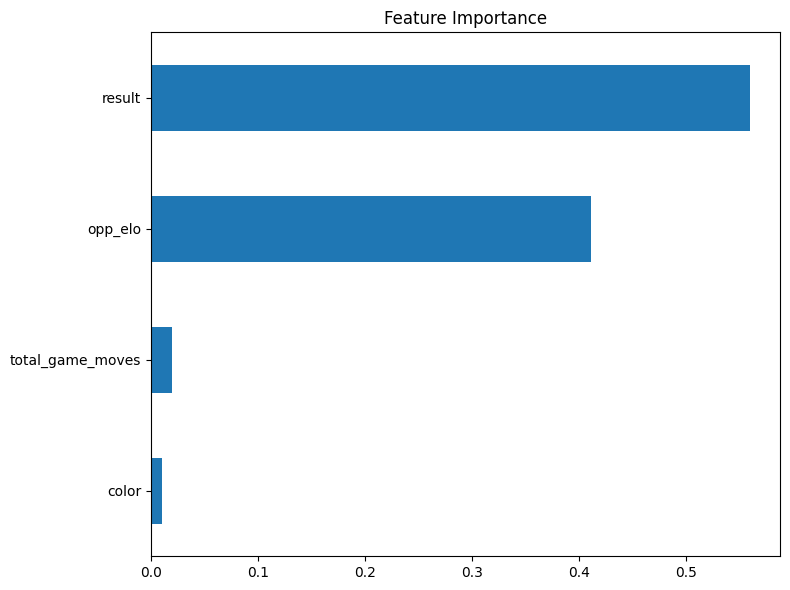


Top 5 features:
result              0.559516
opp_elo             0.410858
total_game_moves    0.019744
color               0.009882
dtype: float32


In [ ]:
importance = pd.Series(model.feature_importances_, index=features)
importance.sort_values().plot(kind='barh', figsize=(8, 6), title='Feature Importance')
plt.tight_layout()
plt.show()

print("\nTop 5 features:")
print(importance.sort_values(ascending=False).head(5))

## Prediction vs Actual

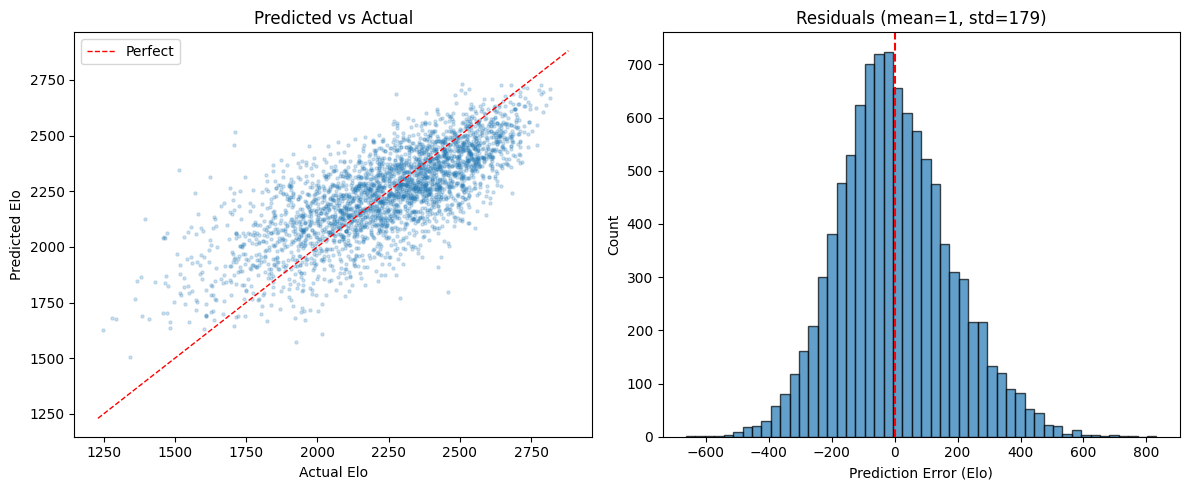

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Scatter: predicted vs actual
sample_idx = np.random.choice(len(y_test), min(3000, len(y_test)), replace=False)
axes[0].scatter(
    np.array(y_test)[sample_idx],
    y_pred[sample_idx],
    alpha=0.2, s=5
)
lo, hi = y_test.min(), y_test.max()
axes[0].plot([lo, hi], [lo, hi], 'r--', lw=1, label='Perfect')
axes[0].set_xlabel('Actual Elo')
axes[0].set_ylabel('Predicted Elo')
axes[0].set_title('Predicted vs Actual')
axes[0].legend()

# Residuals distribution
residuals = y_pred - np.array(y_test)
axes[1].hist(residuals, bins=50, edgecolor='k', alpha=0.7)
axes[1].axvline(0, color='r', linestyle='--')
axes[1].set_xlabel('Prediction Error (Elo)')
axes[1].set_ylabel('Count')
axes[1].set_title(f'Residuals (mean={residuals.mean():.0f}, std={residuals.std():.0f})')

plt.tight_layout()
plt.show()

## Why This Is Still Hard

Even with engine scores, single-game Elo prediction has a ceiling. Here's why:

1. **Variance**: A 2700 player can blunder a piece in a time scramble. One game ≠ true skill.
2. **Opponent strength matters**: Playing a 1500 doesn't stress-test your true ceiling.
3. **Game phase bias**: A quick 20-move win tells you little about endgame skill.

The Kaggle competition winner likely got MAE ~175 Elo. If you're close to that, you're doing well.

**Further improvements to try:**
- Average predictions across multiple games per player (reduces variance)
- Opening ECO code as a categorical feature (some openings correlate with player style/strength)
- Time control features (blitz vs classical games have different cp-loss profiles)
- Neural network on raw move sequences (would need significant compute)